In [4]:
!pip install yfinance
import yfinance as yf
import pandas as pd

# Przykład dla Apple (powtórz to dla 5 różnych tickerów i dat)
ticker = "AAPL"
spolka = yf.Ticker(ticker)
data = spolka.history(start="2023-01-01", end="2024-01-01")

# Wyciągnięcie cen zamknięcia
df = data[['Close']].reset_index()

Pobieranie danych dla: MSFT (2023-01-01 do 2024-01-01)
Pobieranie danych dla: NFLX (2023-06-01 do 2024-01-01)
Pobieranie danych dla: PLTR (2023-09-01 do 2024-03-01)
Pobieranie danych dla: TSLA (2024-01-01 do 2024-04-01)
Pobieranie danych dla: AAPL (2023-03-01 do 2023-09-01)

--- ANALIZA KPI DLA MSFT ---
Braki w danych:
Date     0
Close    0
dtype: int64

Statystyki (Accuracy):
            Close
count  250.000000
mean   307.437306
std     40.816766
min    216.624466
25%    276.448166
50%    318.001862
75%    330.917755
max    376.219147

Opóźnienie (Latency):
Start: 2023-01-03 00:00:00-05:00
Koniec: 2023-12-29 00:00:00-05:00


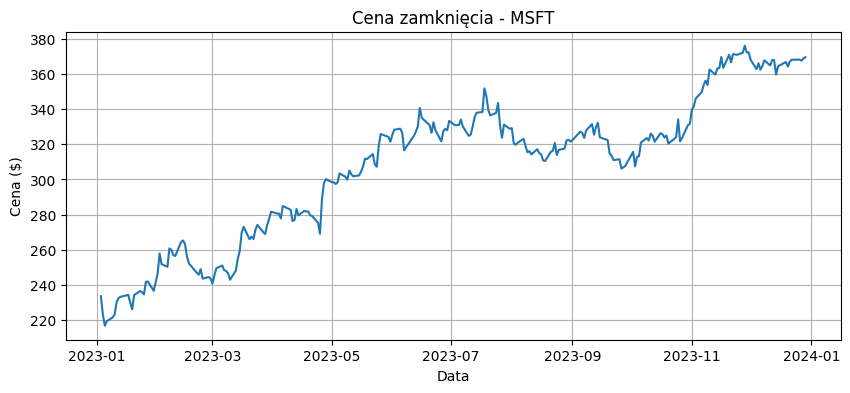

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Definiujemy listę Twoich firm i ich tickery oraz różne zakresy dat
# (Zgodnie z punktem 3 instrukcji: "period of each of 5 companies needed to be different")
spolki_config = {
    "MSFT": ("2023-01-01", "2024-01-01"),  # Cały rok 2023
    "NFLX": ("2023-06-01", "2024-01-01"),  # Ostatnie półrocze 2023
    "PLTR": ("2023-09-01", "2024-03-01"),  # Przełom 2023/24
    "TSLA": ("2024-01-01", "2024-04-01"),  # Pierwszy kwartał 2024
    "AAPL": ("2023-03-01", "2023-09-01")   # Pół roku w środku 2023
}

all_data = {}

for ticker, (start_dt, end_dt) in spolki_config.items():
    print(f"Pobieranie danych dla: {ticker} ({start_dt} do {end_dt})")
    stock = yf.Ticker(ticker)
    df = stock.history(start=start_dt, end=end_dt)
    
    # Przetwarzanie danych zgodnie z kodem nauczyciela (Screenshot 12.48.13)
    df_clean = df[['Close']].reset_index()
    all_data[ticker] = df_clean

# PRZYKŁAD ANALIZY KPI DLA PIERWSZEJ FIRMY (MSFT)
# Zgodnie ze Screenshot 2026-05-03 at 12.48.23.png
test_ticker = "MSFT"
print(f"\n--- ANALIZA KPI DLA {test_ticker} ---")

# 1. Completeness (Brakujące wartości)
print("Braki w danych:")
print(all_data[test_ticker].isnull().sum())

# 2. Basic Stats (Accuracy)
print("\nStatystyki (Accuracy):")
print(all_data[test_ticker].describe())

# 3. Latency (Zakres dat)
# Zgodnie ze Screenshot 2026-05-03 at 12.48.29.png
print("\nOpóźnienie (Latency):")
print("Start:", all_data[test_ticker]['Date'].min())
print("Koniec:", all_data[test_ticker]['Date'].max())

# 4. Wizualizacja
plt.figure(figsize=(10, 4))
plt.plot(all_data[test_ticker]['Date'], all_data[test_ticker]['Close'])
plt.title(f"Cena zamknięcia - {test_ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.grid(True)
plt.show()

In [7]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 3.5 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]


In [8]:
# Install the library if missing
# !pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Setting plot style
plt.style.use('seaborn-v0_8')

In [9]:
# Install the library if missing
# !pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Setting plot style
plt.style.use('seaborn-v0_8')

In [10]:
# Configuration with different time periods for each company
companies = {
    "MSFT": {"start": "2023-01-01", "end": "2023-12-31"},
    "NFLX": {"start": "2023-06-01", "end": "2023-12-31"},
    "PLTR": {"start": "2023-08-01", "end": "2024-02-01"},
    "TSLA": {"start": "2024-01-01", "end": "2024-04-15"},
    "AAPL": {"start": "2023-03-01", "end": "2023-09-01"}
}

datasets = {}

for ticker, dates in companies.items():
    print(f"Downloading data for {ticker}...")
    stock = yf.Ticker(ticker)
    raw_data = stock.history(start=dates['start'], end=dates['end'])
    
    # Process data: Extract Close price and reset index
    df = raw_data[['Close']].reset_index()
    datasets[ticker] = df

In [11]:
for ticker, df in datasets.items():
    print(f"\n{'='*20} KPI Analysis: {ticker} {'='*20}")
    
    # KPI (a): Completeness - Check for missing values
    missing = df['Close'].isnull().sum()
    print(f"1. Completeness: {missing} missing values")
    
    # KPI (b): Latency - Check data range
    start_date = df['Date'].min()
    end_date = df['Date'].max()
    print(f"2. Latency: Data from {start_date.date()} to {end_date.date()}")
    
    # KPI (c): Accuracy - Basic Statistics
    print("3. Accuracy (Descriptive Stats):")
    print(df['Close'].describe())
    
    # KPI (d): Consistency - Data types check
    print(f"4. Consistency: Data types are consistent: {df['Close'].dtype}")

    # Stationarity test (ADF Test) - from teacher's code
    result = adfuller(df['Close'])
    print(f"ADF Statistic: {result[0]}")


==================== KPI Analysis: MSFT ====================
1. Completeness: 0 missing values
2. Latency: Data from 2023-01-03 to 2023-12-29
3. Accuracy (Descriptive Stats):
count    250.000000
mean     307.437303
std       40.816764
min      216.624466
25%      276.448196
50%      318.001877
75%      330.917747
max      376.219147
Name: Close, dtype: float64
4. Consistency: Data types are consistent: float64
ADF Statistic: -1.607046327174736

==================== KPI Analysis: NFLX ====================
1. Completeness: 0 missing values
2. Latency: Data from 2023-06-01 to 2023-12-29
3. Accuracy (Descriptive Stats):
count    147.000000
mean      42.897150
std        3.349476
min       34.618999
25%       40.688499
50%       42.999001
75%       44.698500
max       49.501999
Name: Close, dtype: float64
4. Consistency: Data types are consistent: float64
ADF Statistic: -1.3200683780757907

==================== KPI Analysis: PLTR ====================
1. Completeness: 0 missing values
2. La

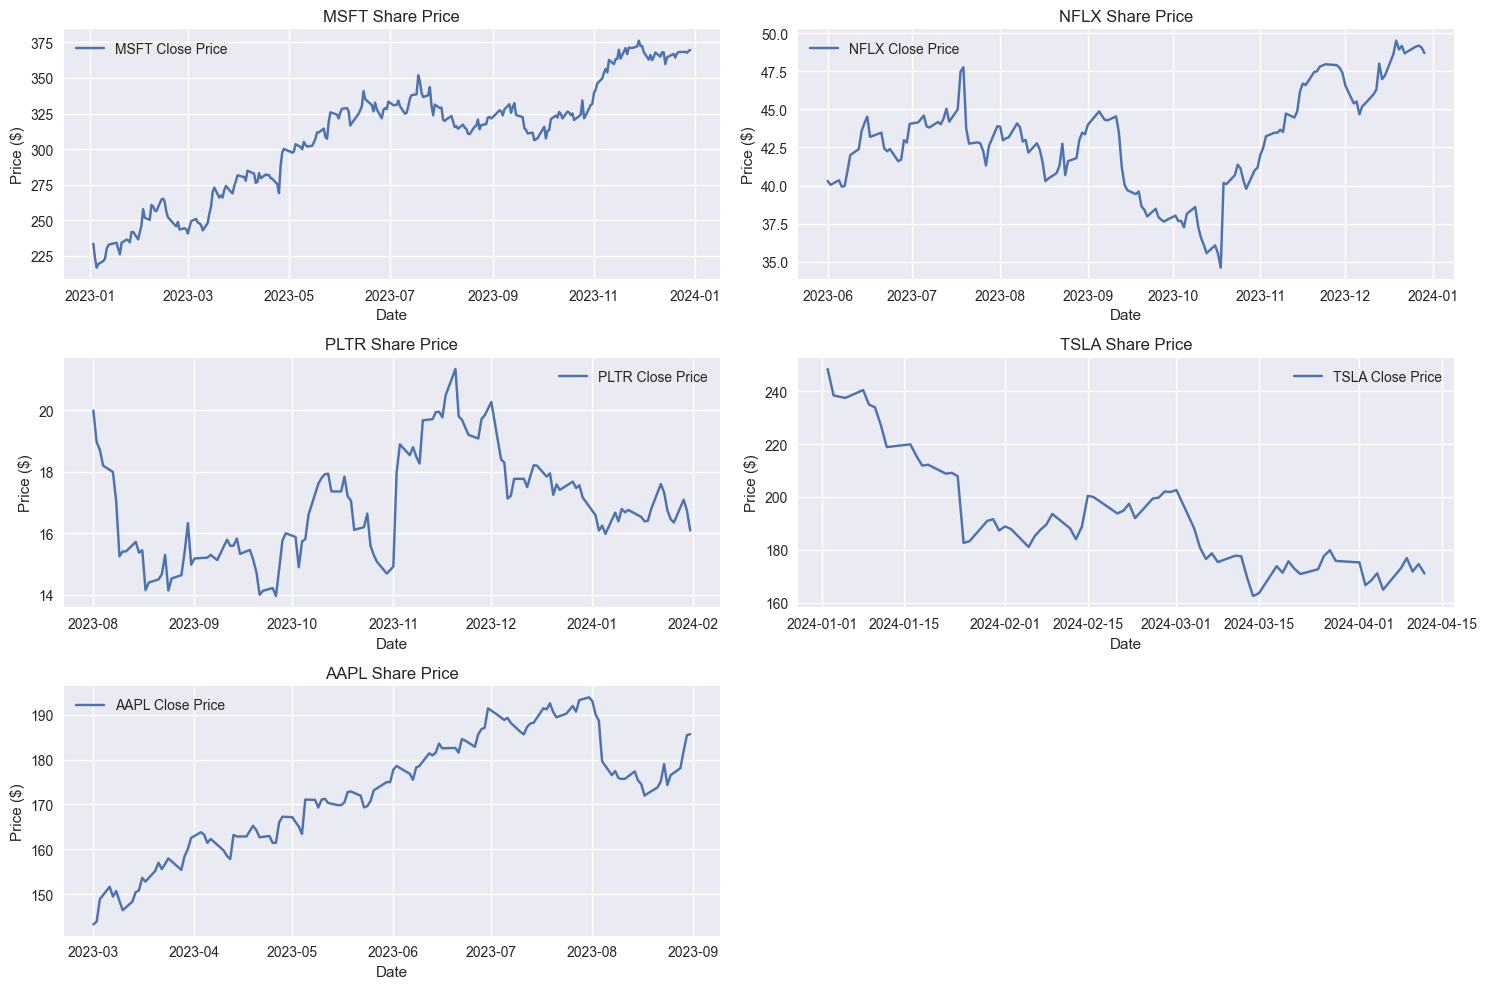

In [12]:
plt.figure(figsize=(15, 10))

for i, (ticker, df) in enumerate(datasets.items(), 1):
    plt.subplot(3, 2, i)
    plt.plot(df['Date'], df['Close'], label=f'{ticker} Close Price')
    plt.title(f"{ticker} Share Price")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()